In [12]:
import numpy as np
import matplotlib.pyplot as plt

def LSQR(x, y):
    n = x.size
    x_sum = np.sum(x)
    y_sum = np.sum(y)
    x2_sum = np.sum(x**2)
    xy_sum = np.sum(x * y)
    
    m = (n*xy_sum - x_sum*y_sum) / (n*x2_sum - x_sum**2)
    c = (y_sum - m*x_sum) / n
    return m, c

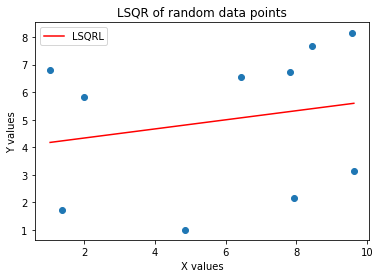

In [13]:
#part 1 using my function

plt.figure()

#getting values
x_values = np.random.rand(10)
x_values = 10*np.sort(x_values)
y_values = 10*np.random.rand(10)

m, c = LSQR(x_values,y_values)

plt.scatter(x_values,y_values)

x = np.linspace(x_values.min(),x_values.max(),100)
y = m*x+c

plt.plot(x, y, color='red', label='LSQRL') 
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('LSQR of random data points')
plt.legend()
plt.show()

plt.show()

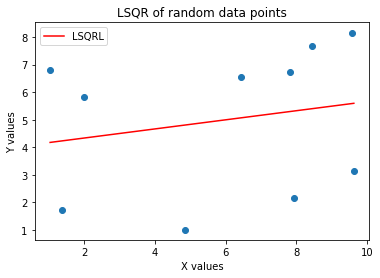

In [14]:
#part 1 using Numpy

plt.figure()

A = np.vstack([x_values, np.ones(len(x_values))]).T
m, c = np.linalg.lstsq(A, y_values, rcond=None)[0]

plt.scatter(x_values,y_values)

x = np.linspace(x_values.min(),x_values.max(),100)
y = m*x+c

plt.plot(x, y, color='red', label='LSQRL') 
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('LSQR of random data points')
plt.legend()
plt.show()

plt.show()

Original Equation:  y = 6.890171025107787x + -8.350785411876714
Predicted Equation: y = 6.452129673193745x + -8.113077184046006

Max Residual of 1.084447116039029 at X = 0.76
Min Residual of -1.1108196910053092 at X = 0.08

Largest absolute Residual of 1.1108196910053092 at X = 0.08
Smallest absolute Residual of 0.00407014933852512 at X = 0.17


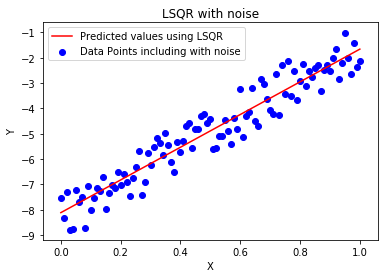

In [18]:
#part 2 using my function
#Compare to using it with numpy function
# random linear function
realM = np.random.uniform(-10,10)
realB = np.random.uniform(-10,10)

#Data
X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, size=X.shape)
Y = realM * X + realB + noise

#solving LSQR using my function
PredictedM, PredictedB = LSQR(X,Y)

#Residuals
PredictedY = PredictedM * X + PredictedB
residual = Y - PredictedY
absolute_residuals = np.abs(residual)

max_abs = np.argmax(absolute_residuals)
min_abs = np.argmin(absolute_residuals)


Xmax = np.argmax(residual)
Xmin = np.argmin(residual)

# Outputed equations
print(f"Original Equation:  y = {realM}x + {realB:}")
print(f"Predicted Equation: y = {PredictedM}x + {PredictedB}")
print("")

#Residuals
print(f"Max Residual of {residual[Xmax]} at X = {X[Xmax]}")
print(f"Min Residual of {residual[Xmin]} at X = {X[Xmin]}")
print('')
print(f"Largest absolute Residual of {absolute_residuals[max_abs]} at X = {X[max_abs]}")
print(f"Smallest absolute Residual of {absolute_residuals[min_abs]} at X = {X[min_abs]}")

# Graphing
plt.scatter(X, Y, color='blue', label='Data Points including with noise')
plt.plot(X, PredictedY, color='red', label=f'Predicted values using LSQR')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('LSQR with noise')
plt.legend()
plt.show()

Original Equation:  y = 6.890171025107787x + -8.350785411876714
Predicted Equation: y = 6.452129673193751x + -8.113077184046007

Max Residual of 1.0844471160390272 at X = 0.76
Min Residual of -1.1108196910053074 at X = 0.08

Largest absolute Residual of 1.1108196910053074 at X = 0.08
Smallest absolute Residual of 0.004070149338526008 at X = 0.17


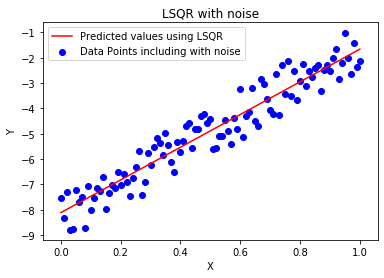

In [19]:
#solving LSQR using numpy
A = np.vstack([X, np.ones(len(X))]).T
PredictedM, PredictedB = np.linalg.lstsq(A, Y, rcond=None)[0]

#Residuals
PredictedY = PredictedM * X + PredictedB
residual = Y - PredictedY
absolute_residuals = np.abs(residual)

max_abs = np.argmax(absolute_residuals)
min_abs = np.argmin(absolute_residuals)


Xmax = np.argmax(residual)
Xmin = np.argmin(residual)

# Outputed equations
print(f"Original Equation:  y = {realM}x + {realB:}")
print(f"Predicted Equation: y = {PredictedM}x + {PredictedB}")
print("")

#Residuals
print(f"Max Residual of {residual[Xmax]} at X = {X[Xmax]}")
print(f"Min Residual of {residual[Xmin]} at X = {X[Xmin]}")
print('')
print(f"Largest absolute Residual of {absolute_residuals[max_abs]} at X = {X[max_abs]}")
print(f"Smallest absolute Residual of {absolute_residuals[min_abs]} at X = {X[min_abs]}")

# Graphing
plt.scatter(X, Y, color='blue', label='Data Points including with noise')
plt.plot(X, PredictedY, color='red', label=f'Predicted values using LSQR')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('LSQR with noise')
plt.legend()
plt.show()